In [ ]:
import random

def generate(min_val, max_val):
    return random.randint(min_val, max_val)

def create_vectors(problem_size, min_val, max_val):
    return [generate(min_val, max_val) for _ in range (problem_size)]

#fitnesses
def compute_cost(vector):
    return sum(val*val for val in vector)

def exchange(vector1,vector2, problem_size, rate =0.9):
    vector1_new = vector1.copy()
    vector2_new = vector2.copy()

    for i in range (problem_size):
        if random.random() < rate:
            vector1_new[i] = vector2[i]
            vector2_new[i] = vector1[i]
    
    return vector1_new, vector2_new

#mutation
def explore(vector, problem_size,min_val, max_val, rate =0.05):
    vector_m = vector.copy()
    for i in range(problem_size):
        if random.random() < rate:
            vector_m[i] = generate(min_val, max_val)
        
    return vector_m


#Selection
def selection(sorted_vector, nums_of_members):
    index1 = random.randint(0, nums_of_members - 1)
    index2 = random.randint(0, nums_of_members - 1)
    
    while index1 == index2:
         index2 = random.randint(0, nums_of_members - 1)

    if index1 < index2:
        return sorted_vector[index1]
    
    return sorted_vector[index2]



In [17]:
problem_size = 5          # size of individual (chromosome)
nums_of_members = 100     # size of population
n_generations = 100       # number of generations
min_value, max_value = -50, 50

costs = []

vectors = [create_vectors(problem_size, min_value, max_value) for _ in range (nums_of_members)]

elitism = 2
for i in range(n_generations):

    sorted_vector = sorted(vectors, key =compute_cost )

    if i % 10==0:
        costs.append(compute_cost(sorted_vector[0]))
        print('Best', compute_cost(sorted_vector[0]))

    # create new_population (get the first two)
    new_vectors = []
    new_vectors = sorted_vector[:elitism]

    while len(new_vectors) < nums_of_members:
        #Selection
        vector1 = selection(sorted_vector, nums_of_members)
        vector2 = selection(sorted_vector, nums_of_members)

        #exchange
        vector1_new, vector2_new = exchange(vector1,vector2, problem_size)

        #mutation

        vector1_new = explore(vector1_new , problem_size,min_value, max_value)
        vector2_new = explore(vector2_new , problem_size,min_value, max_value)

        new_vectors.append(vector1_new)
        new_vectors.append(vector2_new)

    vectors = new_vectors




Best 1416
Best 118
Best 19
Best 14
Best 1
Best 0
Best 0
Best 0
Best 0
Best 0


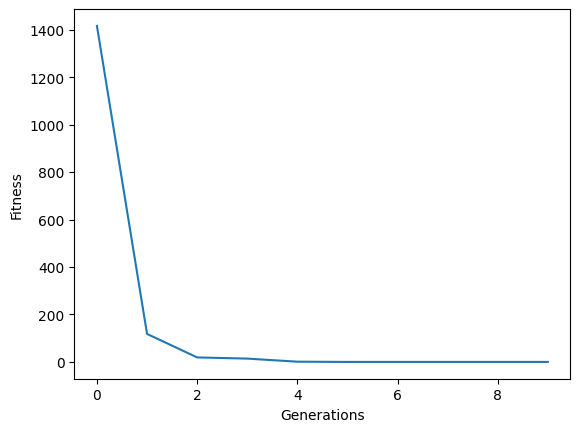

In [18]:
import matplotlib.pyplot as plt

plt.plot(costs)
plt.xlabel('Generations')
plt.ylabel('Fitness')
plt.show()